In [4]:
import pandas as pd
import numpy as np 
import wfdb

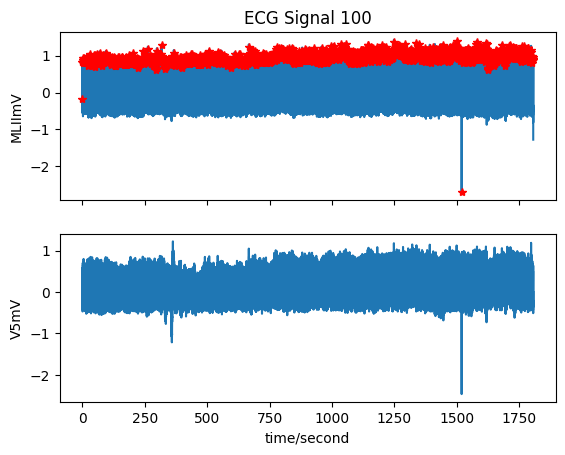

In [5]:
record = wfdb.rdrecord("mit-bih-arrhythmia-database-1.0.0/100")
annotation = wfdb.rdann("mit-bih-arrhythmia-database-1.0.0/100", "atr")

# Affichage de la forme du signal et des annotations
wfdb.plot_wfdb(record=record, annotation=annotation, title='ECG Signal 100')

In [1]:
import os
def get_record_names(folder_path):
    record_names = []
    for file in os.listdir(folder_path):
        if file.endswith(".dat"):
            # Remove extension to get the base record name (e.g., "100")
            record_name = os.path.splitext(file)[0]
            record_names.append(record_name)
    
    # Remove duplicates if any (in case multiple extensions like .hea, .atr exist)
    return sorted(list(set(record_names)))

# Example usage
base_path = "mit-bih-arrhythmia-database-1.0.0"
records = get_record_names(base_path)

print(records)  # ['100', '101', '102', ...]

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [ ]:
from scipy.signal import find_peaks

def extract_features_from_record(record_name, base_path):
    record = wfdb.rdrecord(f"{base_path}/{record_name}")
    annotation = wfdb.rdann(f"{base_path}/{record_name}", 'atr')
    
    signal = record.p_signal[:, 0]  # Assuming we use the first lead
    fs = record.fs  # Sampling frequency

    # Find R-peaks using annotation sample points (or use scipy if needed)
    r_peaks = annotation.sample
    rr_intervals = np.diff(r_peaks) / fs  # in seconds

    features = {
        "record": record_name,
        "mean_rr": np.mean(rr_intervals),
        "std_rr": np.std(rr_intervals),
        "min_rr": np.min(rr_intervals),
        "max_rr": np.max(rr_intervals),
        "num_beats": len(rr_intervals),
        "signal_energy": np.sum(signal ** 2),
        "signal_entropy": -np.sum((signal**2) * np.log(signal**2 + 1e-10))
    }

    return features

# List of record names (you can scan the folder to get them automatically)
base_path = "mit-bih-arrhythmia-database-1.0.0"

data = []
for record in records:
    try:
        features = extract_features_from_record(record, base_path)
        data.append(features)
    except Exception as e:
        print(f"Error with record {record}: {e}")

# Save to CSV
df = pd.DataFrame(data)
df.to_csv("ecg_features.csv", index=False)
